# 🚖 Predicting Uber Ride Cancellations — End-to-End MLOps

**Full lifecycle:** Data → Feature Engineering (No Leakage) → MLflow Tracking → Business Metrics → FastAPI Deployment → Drift Monitoring

---

| | |
|---|---|
| **Dataset** | Uber Ride Analytics — 150,000 bookings |
| **Task** | Binary classification: Will the customer cancel? |
| **Best Model** | XGBoost — AUC = 0.964 (corrected, no leakage) |
| **Business Value** | $11,362 savings per 15K rides (72.1% cost reduction) |
| **Key Fix** | Customer history computed from train set only — eliminates leakage |
| **Deployment** | FastAPI REST API with single + batch prediction |
| **Monitoring** | PSI + KS drift detection, automated retraining triggers |

## 1. 🎯 Problem Statement

Every cancelled ride = **lost revenue + wasted driver dispatch + customer churn risk**.

**Goal:** Predict whether a customer will cancel their booking **before the ride begins**, using only pre-ride metadata — with zero data leakage.

| | |
|---|---|
| **Task** | Binary Classification |
| **Target** | `target_customer_cancelled` (1 = cancelled, 0 = not) |
| **Class Imbalance** | ~7% cancellations (13.3 : 1 ratio) |
| **Key Constraint** | Only features available *before* the ride starts |

## 2. 📦 Setup & Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow, mlflow.sklearn, mlflow.xgboost
import xgboost as xgb
import joblib, json, shap, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import (roc_auc_score, classification_report,
                              confusion_matrix, roc_curve,
                              precision_recall_curve, average_precision_score,
                              f1_score, precision_score, recall_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

print('✅ All libraries imported')
print(f'   XGBoost : {xgb.__version__}')
print(f'   MLflow  : {mlflow.__version__}')

✅ All libraries imported
   XGBoost : 3.2.0
   MLflow  : 3.11.1


## 3. 📂 Load Data

In [ ]:
df = pd.read_csv('UBERDATA.csv')
print(f'✅ Loaded {len(df):,} rows × {df.shape[1]} columns')
print(f'\nBooking Status distribution:')
print(df['Booking Status'].value_counts())
df.head(3)

✅ Loaded 150,000 rows × 21 columns

Booking Status distribution:
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000


In [ ]:
print('Null values per column:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Null values per column:
Cancelled Rides by Customer         139500
Reason for cancelling by Customer   139500
Cancelled Rides by Driver           123000
Driver Cancellation Reason          123000
Incomplete Rides                    141000
Incomplete Rides Reason             141000
Booking Value                        48000
Ride Distance                        57000
Driver Ratings                       57000
Customer Rating                      93000
Payment Method                       48000


## 4. 📊 Exploratory Data Analysis

Key patterns explored:
- Cancellation rate by vehicle type, hour, day of week
- Payment method vs cancellation
- VTAT / CTAT distribution
- Customer-level cancellation patterns

In [ ]:
df['target_customer_cancelled'] = (df['Booking Status'] == 'Cancelled by Customer').astype(int)
rate = df['target_customer_cancelled'].mean()
print(f'🎯 Cancellation Rate : {rate:.2%}')
print(f'   Cancelled         : {df["target_customer_cancelled"].sum():,}')
print(f'   Not Cancelled     : {(df["target_customer_cancelled"]==0).sum():,}')
print(f'\n⚠️  Class imbalance (neg:pos) = {(1-rate)/rate:.1f} : 1')

🎯 Cancellation Rate : 7.00%
   Cancelled         : 10,500
   Not Cancelled     : 139,500

⚠️  Class imbalance (neg:pos) = 13.3 : 1


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. By Vehicle Type
df_tmp = df.copy()
df_tmp['hour'] = pd.to_datetime(df_tmp['Time'], format='%H:%M:%S', errors='coerce').dt.hour
vc = df_tmp.groupby('Vehicle Type')['target_customer_cancelled'].mean().sort_values(ascending=False)
axes[0,0].bar(vc.index, vc.values, color='#4C72B0', edgecolor='white')
axes[0,0].set_title('Cancellation Rate by Vehicle Type', fontweight='bold')
axes[0,0].set_xticklabels(vc.index, rotation=30, ha='right')
axes[0,0].set_ylabel('Cancellation Rate')

# 2. By Hour
hourly = df_tmp.groupby('hour')['target_customer_cancelled'].mean()
axes[0,1].plot(hourly.index, hourly.values, marker='o', color='#DD8452', lw=2)
axes[0,1].axhline(rate, color='gray', linestyle='--', alpha=0.5, label='Baseline')
axes[0,1].set_title('Cancellation Rate by Hour', fontweight='bold')
axes[0,1].set_xlabel('Hour of Day'); axes[0,1].legend()

# 3. By Day of Week
df_tmp['weekday'] = pd.to_datetime(df_tmp['Date'], errors='coerce').dt.dayofweek
daily = df_tmp.groupby('weekday')['target_customer_cancelled'].mean()
axes[1,0].bar(range(7), daily.values, color='#55A868', edgecolor='white')
axes[1,0].set_xticks(range(7))
axes[1,0].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
axes[1,0].set_title('Cancellation Rate by Day of Week', fontweight='bold')

# 4. Payment Method
pm = df_tmp.groupby('Payment Method')['target_customer_cancelled'].mean().sort_values()
axes[1,1].barh(pm.index, pm.values, color='#C44E52', edgecolor='white')
axes[1,1].set_title('Cancellation Rate by Payment Method', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=120, bbox_inches='tight')
plt.show()
print('EDA complete')

EDA complete


## 5. 🔧 Feature Engineering — Corrected (No Leakage)

> ⚠️ **Critical Fix:** Customer history features (`customer_cancel_history`, `customer_total_bookings`) must be computed **AFTER** the train/test split — using training data only. Computing them on the full dataset before splitting causes **target leakage**, which was the root cause of the artificially perfect AUC = 1.00 seen previously.

### Features Created

| Category | Features |
|---|---|
| **Temporal** | hour, day, month, weekday, is_weekend, is_peak, time_period |
| **Wait times** | Avg VTAT, Avg CTAT |
| **Missing flags** | missing_driver_rating, missing_customer_rating, missing_booking_value |
| **Categorical** | vehicle_type (OHE), payment_method (OHE), pickup/drop top-10 (OHE) |
| **Customer** | customer_total_bookings, customer_cancel_history ← computed from TRAIN only |

### Features Excluded (Post-Ride / Leaky)
| Excluded | Reason |
|---|---|
| Booking Value | Only known after ride completes |
| Ride Distance | Only known after ride completes |
| Driver Ratings | Only given after ride |
| Customer Rating | Only given after ride |

In [ ]:
# ── STEP 1: Temporal features ─────────────────────────────────────────────
df['Date']       = pd.to_datetime(df['Date'], errors='coerce')
df['Time']       = pd.to_datetime(df['Time'], format='%H:%M:%S', errors='coerce').dt.time
df['datetime']   = pd.to_datetime(df['Date'].astype(str)+' '+df['Time'].astype(str), errors='coerce')
df['hour']       = df['datetime'].dt.hour
df['day']        = df['datetime'].dt.day
df['month']      = df['datetime'].dt.month
df['weekday']    = df['datetime'].dt.dayofweek
df['is_weekend'] = df['weekday'].isin([5, 6]).astype(int)
df['is_peak']    = df['hour'].isin([7,8,9,17,18,19,20]).astype(int)
df['time_period']= pd.cut(df['hour'], bins=[-1,6,12,17,21,24],
                           labels=['Night','Morning','Afternoon','Evening','Late'])

# ── STEP 2: Target variable ────────────────────────────────────────────────
df['target_customer_cancelled'] = (df['Booking Status'] == 'Cancelled by Customer').astype(int)

# ── STEP 3: Missing value flags (known at booking time) ───────────────────
for col, flag in [('Driver Ratings',  'missing_driver_rating'),
                  ('Customer Rating', 'missing_customer_rating'),
                  ('Booking Value',   'missing_booking_value'),
                  ('Payment Method',  'missing_payment')]:
    df[flag] = df[col].isnull().astype(int)

# ── STEP 4: Fill wait times ────────────────────────────────────────────────
df['Avg VTAT'] = df['Avg VTAT'].fillna(df['Avg VTAT'].median())
df['Avg CTAT'] = df['Avg CTAT'].fillna(df['Avg CTAT'].median())

# ── STEP 5: Categorical encoding ──────────────────────────────────────────
df = pd.get_dummies(df, columns=['Vehicle Type'], prefix='vehicle', drop_first=True)
df['Payment Method'] = df['Payment Method'].fillna('Unknown')
df = pd.get_dummies(df, columns=['Payment Method'], prefix='pay', drop_first=True)

for loc_col, prefix in [('Pickup Location','pickup'), ('Drop Location','drop')]:
    top_locs = df[loc_col].value_counts().nlargest(10).index
    df[f'{prefix}_enc'] = df[loc_col].apply(lambda x: x if x in top_locs else 'Other')
    df = pd.get_dummies(df, columns=[f'{prefix}_enc'], prefix=prefix, drop_first=True)

df = pd.get_dummies(df, columns=['time_period'], prefix='tp', drop_first=True)

# ── STEP 6: Define base features (Customer ID kept separate for now) ───────
leaky_columns = [
    'Booking Status', 'Cancelled Rides by Customer',
    'Reason for cancelling by Customer', 'Cancelled Rides by Driver',
    'Driver Cancellation Reason', 'Incomplete Rides', 'Incomplete Rides Reason',
    'Booking ID', 'Pickup Location', 'Drop Location', 'Date', 'Time', 'datetime',
    'Booking Value', 'Ride Distance', 'Driver Ratings', 'Customer Rating'
]

base_features = [c for c in df.columns
                 if c not in leaky_columns + ['target_customer_cancelled', 'Customer ID']]

X_base = df[base_features].select_dtypes(include=['number','bool']).astype(float)
y      = df['target_customer_cancelled']
cust   = df['Customer ID']

print(f'✅ Base features (before customer aggregation): {X_base.shape[1]}')
print(f'   Target distribution: {y.value_counts().to_dict()}')

✅ Base features (before customer aggregation): 47
   Target distribution: {0: 139500, 1: 10500}


## 6. ✂️ Train / Validation / Test Split

> **Split happens here — BEFORE any customer-level aggregation.**

This is the key fix. Customer booking frequency and cancellation history are computed only from training rows and then *mapped* to validation and test sets.

In [ ]:
# ── SPLIT FIRST ────────────────────────────────────────────────────────────
idx = np.arange(len(df))

# 80% train | 10% validation | 10% test  (stratified)
train_idx, tmp_idx = train_test_split(idx, test_size=0.2, stratify=y, random_state=42)
val_idx,   test_idx= train_test_split(tmp_idx, test_size=0.5,
                                       stratify=y.iloc[tmp_idx], random_state=42)

def make_split(ix):
    return (X_base.iloc[ix].copy().reset_index(drop=True),
            y.iloc[ix].reset_index(drop=True),
            cust.iloc[ix].reset_index(drop=True))

X_tr_base, y_tr, c_tr   = make_split(train_idx)
X_val_base, y_val, c_val = make_split(val_idx)
X_te_base,  y_te,  c_te  = make_split(test_idx)

# ── COMPUTE CUSTOMER FEATURES FROM TRAIN ONLY ✅ ──────────────────────────
cust_booking_freq   = c_tr.value_counts().to_dict()
cust_cancel_history = c_tr[y_tr == 1].value_counts().to_dict()

for X_part, c_part in [(X_tr_base, c_tr), (X_val_base, c_val), (X_te_base, c_te)]:
    # Unseen customers in val/test map to 0 (no prior history)
    X_part['customer_total_bookings'] = c_part.map(cust_booking_freq).fillna(0).values
    X_part['customer_cancel_history'] = c_part.map(cust_cancel_history).fillna(0).values

feature_names = X_tr_base.columns.tolist()

print(f'✅ Split complete — customer history computed from TRAIN only')
print(f'   Train : {len(X_tr_base):>7,} rows  ({y_tr.mean():.2%} cancellation rate)')
print(f'   Val   : {len(X_val_base):>7,} rows  ({y_val.mean():.2%} cancellation rate)')
print(f'   Test  : {len(X_te_base):>7,} rows  ({y_te.mean():.2%} cancellation rate)')
print(f'   Total features: {len(feature_names)}')

✅ Split complete — customer history computed from TRAIN only
   Train : 120,000 rows  (7.00% cancellation rate)
   Val   :  15,000 rows  (7.00% cancellation rate)
   Test  :  15,000 rows  (7.00% cancellation rate)
   Total features: 49


In [ ]:
# ── Impute missing values (fit on TRAIN only) ─────────────────────────────
imputer = SimpleImputer(strategy='median')
X_tr  = imputer.fit_transform(X_tr_base)   # fit + transform
X_val = imputer.transform(X_val_base)      # transform only
X_te  = imputer.transform(X_te_base)       # transform only

scale_pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()
print(f'✅ Imputation complete')
print(f'   scale_pos_weight (XGBoost) = {scale_pos_weight:.2f}')

✅ Imputation complete
   scale_pos_weight (XGBoost) = 13.29


## 7. 🔬 Experiment Tracking with MLflow

All runs logged with parameters, metrics, and model artifacts.

> **Threshold selection:** Instead of a fixed 0.5, we use **Youden's J statistic** on the validation set: `threshold = argmax(TPR − FPR)`. This maximises sensitivity + specificity and avoids overfitting the threshold to the test set.

In [ ]:
mlflow.set_tracking_uri('./mlruns')
mlflow.set_experiment('Uber_Cancellation_Prediction')

def youden_threshold(y_true, y_prob):
    """Find threshold that maximises Youden's J = TPR - FPR."""
    from sklearn.metrics import roc_curve
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    j_scores = tpr - fpr
    return float(thresholds[np.argmax(j_scores)])

def evaluate(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        'auc':       round(float(roc_auc_score(y_true, y_prob)), 4),
        'f1':        round(float(f1_score(y_true, y_pred, zero_division=0)), 4),
        'ap':        round(float(average_precision_score(y_true, y_prob)), 4),
        'precision': round(float(precision_score(y_true, y_pred, zero_division=0)), 4),
        'recall':    round(float(recall_score(y_true, y_pred, zero_division=0)), 4),
        'threshold': round(float(threshold), 4),
        'preds': y_pred, 'probs': y_prob
    }

results = {}

# ── Logistic Regression ───────────────────────────────────────────────────
with mlflow.start_run(run_name='Logistic_Regression'):
    lr = LogisticRegression(class_weight='balanced', max_iter=1000, C=1.0, random_state=42)
    lr.fit(X_tr, y_tr)
    lr_t = youden_threshold(y_val, lr.predict_proba(X_val)[:,1])
    m = evaluate(y_te, lr.predict_proba(X_te)[:,1], lr_t)
    mlflow.log_params({'model':'LogisticRegression','threshold':lr_t,'C':1.0})
    mlflow.log_metrics({'roc_auc':m['auc'],'f1_score':m['f1'],'avg_precision':m['ap']})
    results['Logistic Regression'] = m
    print(f'Logistic Regression → AUC={m["auc"]}  F1={m["f1"]}  Recall={m["recall"]}  t={lr_t:.4f}')

# ── Random Forest ─────────────────────────────────────────────────────────
with mlflow.start_run(run_name='Random_Forest'):
    rf = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                max_depth=10, min_samples_leaf=5, random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    rf_t = youden_threshold(y_val, rf.predict_proba(X_val)[:,1])
    m = evaluate(y_te, rf.predict_proba(X_te)[:,1], rf_t)
    mlflow.log_params({'model':'RandomForest','n_estimators':200,'threshold':rf_t})
    mlflow.log_metrics({'roc_auc':m['auc'],'f1_score':m['f1'],'avg_precision':m['ap']})
    results['Random Forest'] = m
    print(f'Random Forest       → AUC={m["auc"]}  F1={m["f1"]}  Recall={m["recall"]}  t={rf_t:.4f}')

# ── XGBoost ───────────────────────────────────────────────────────────────
xgb_params = dict(objective='binary:logistic', eval_metric='auc',
                   scale_pos_weight=scale_pos_weight, n_estimators=300, max_depth=6,
                   learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
                   random_state=42, n_jobs=-1)
with mlflow.start_run(run_name='XGBoost_Tuned'):
    xgb_model = xgb.XGBClassifier(**xgb_params)
    xgb_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    xgb_t = youden_threshold(y_val, xgb_model.predict_proba(X_val)[:,1])
    m = evaluate(y_te, xgb_model.predict_proba(X_te)[:,1], xgb_t)
    mlflow.log_params({**xgb_params,'threshold':xgb_t})
    mlflow.log_metrics({'roc_auc':m['auc'],'f1_score':m['f1'],'avg_precision':m['ap']})
    mlflow.xgboost.log_model(xgb_model,'xgb_model')
    results['XGBoost'] = m
    print(f'XGBoost             → AUC={m["auc"]}  F1={m["f1"]}  Recall={m["recall"]}  t={xgb_t:.4f}')

print('\n✅ All experiments logged to MLflow')
print('   Run `mlflow ui` in terminal to open the tracking dashboard')

Logistic Regression → AUC=0.9344  F1=0.3569  Recall=0.9705  t=0.0109
Random Forest       → AUC=0.9496  F1=0.3964  Recall=0.9981  t=0.1423
XGBoost             → AUC=0.9638  F1=0.4963  Recall=0.9867  t=0.0001

✅ All experiments logged to MLflow
   Run `mlflow ui` in terminal to open the tracking dashboard


## 8. 📈 Model Evaluation & Comparison

In [ ]:
# Summary comparison table
print('Model Comparison (Corrected — No Leakage):\n')
print(f'{"Model":<22} {"AUC":>7} {"F1":>7} {"Precision":>10} {"Recall":>8} {"Threshold":>10}')
print('-'*68)
for name, r in results.items():
    star = ' ⭐' if name == 'XGBoost' else ''
    print(f'{name+star:<24} {r["auc"]:>7} {r["f1"]:>7} {r["precision"]:>10} {r["recall"]:>8} {r["threshold"]:>10}')

Model Comparison (Corrected — No Leakage):

Model                    AUC      F1  Precision   Recall  Threshold
--------------------------------------------------------------------
Logistic Regression    0.9344  0.3569      0.219   0.9705      0.0109
Random Forest          0.9496  0.3964      0.247   0.9981      0.1423
XGBoost ⭐             0.9638  0.4963      0.332   0.9867      0.0001


In [ ]:
# Classification Report — XGBoost
print('Detailed Classification Report — XGBoost (Best Model):\n')
from sklearn.metrics import classification_report
print(classification_report(y_te, results['XGBoost']['preds'],
                            target_names=['Not Cancelled','Cancelled'], digits=3))

Detailed Classification Report — XGBoost (Best Model):

               precision    recall  f1-score   support

Not Cancelled      0.999     0.850     0.919     13950
    Cancelled      0.332     0.987     0.496      1050

     accuracy                          0.860     15000
    macro avg      0.665     0.918     0.707     15000
 weighted avg      0.952     0.860     0.889     15000


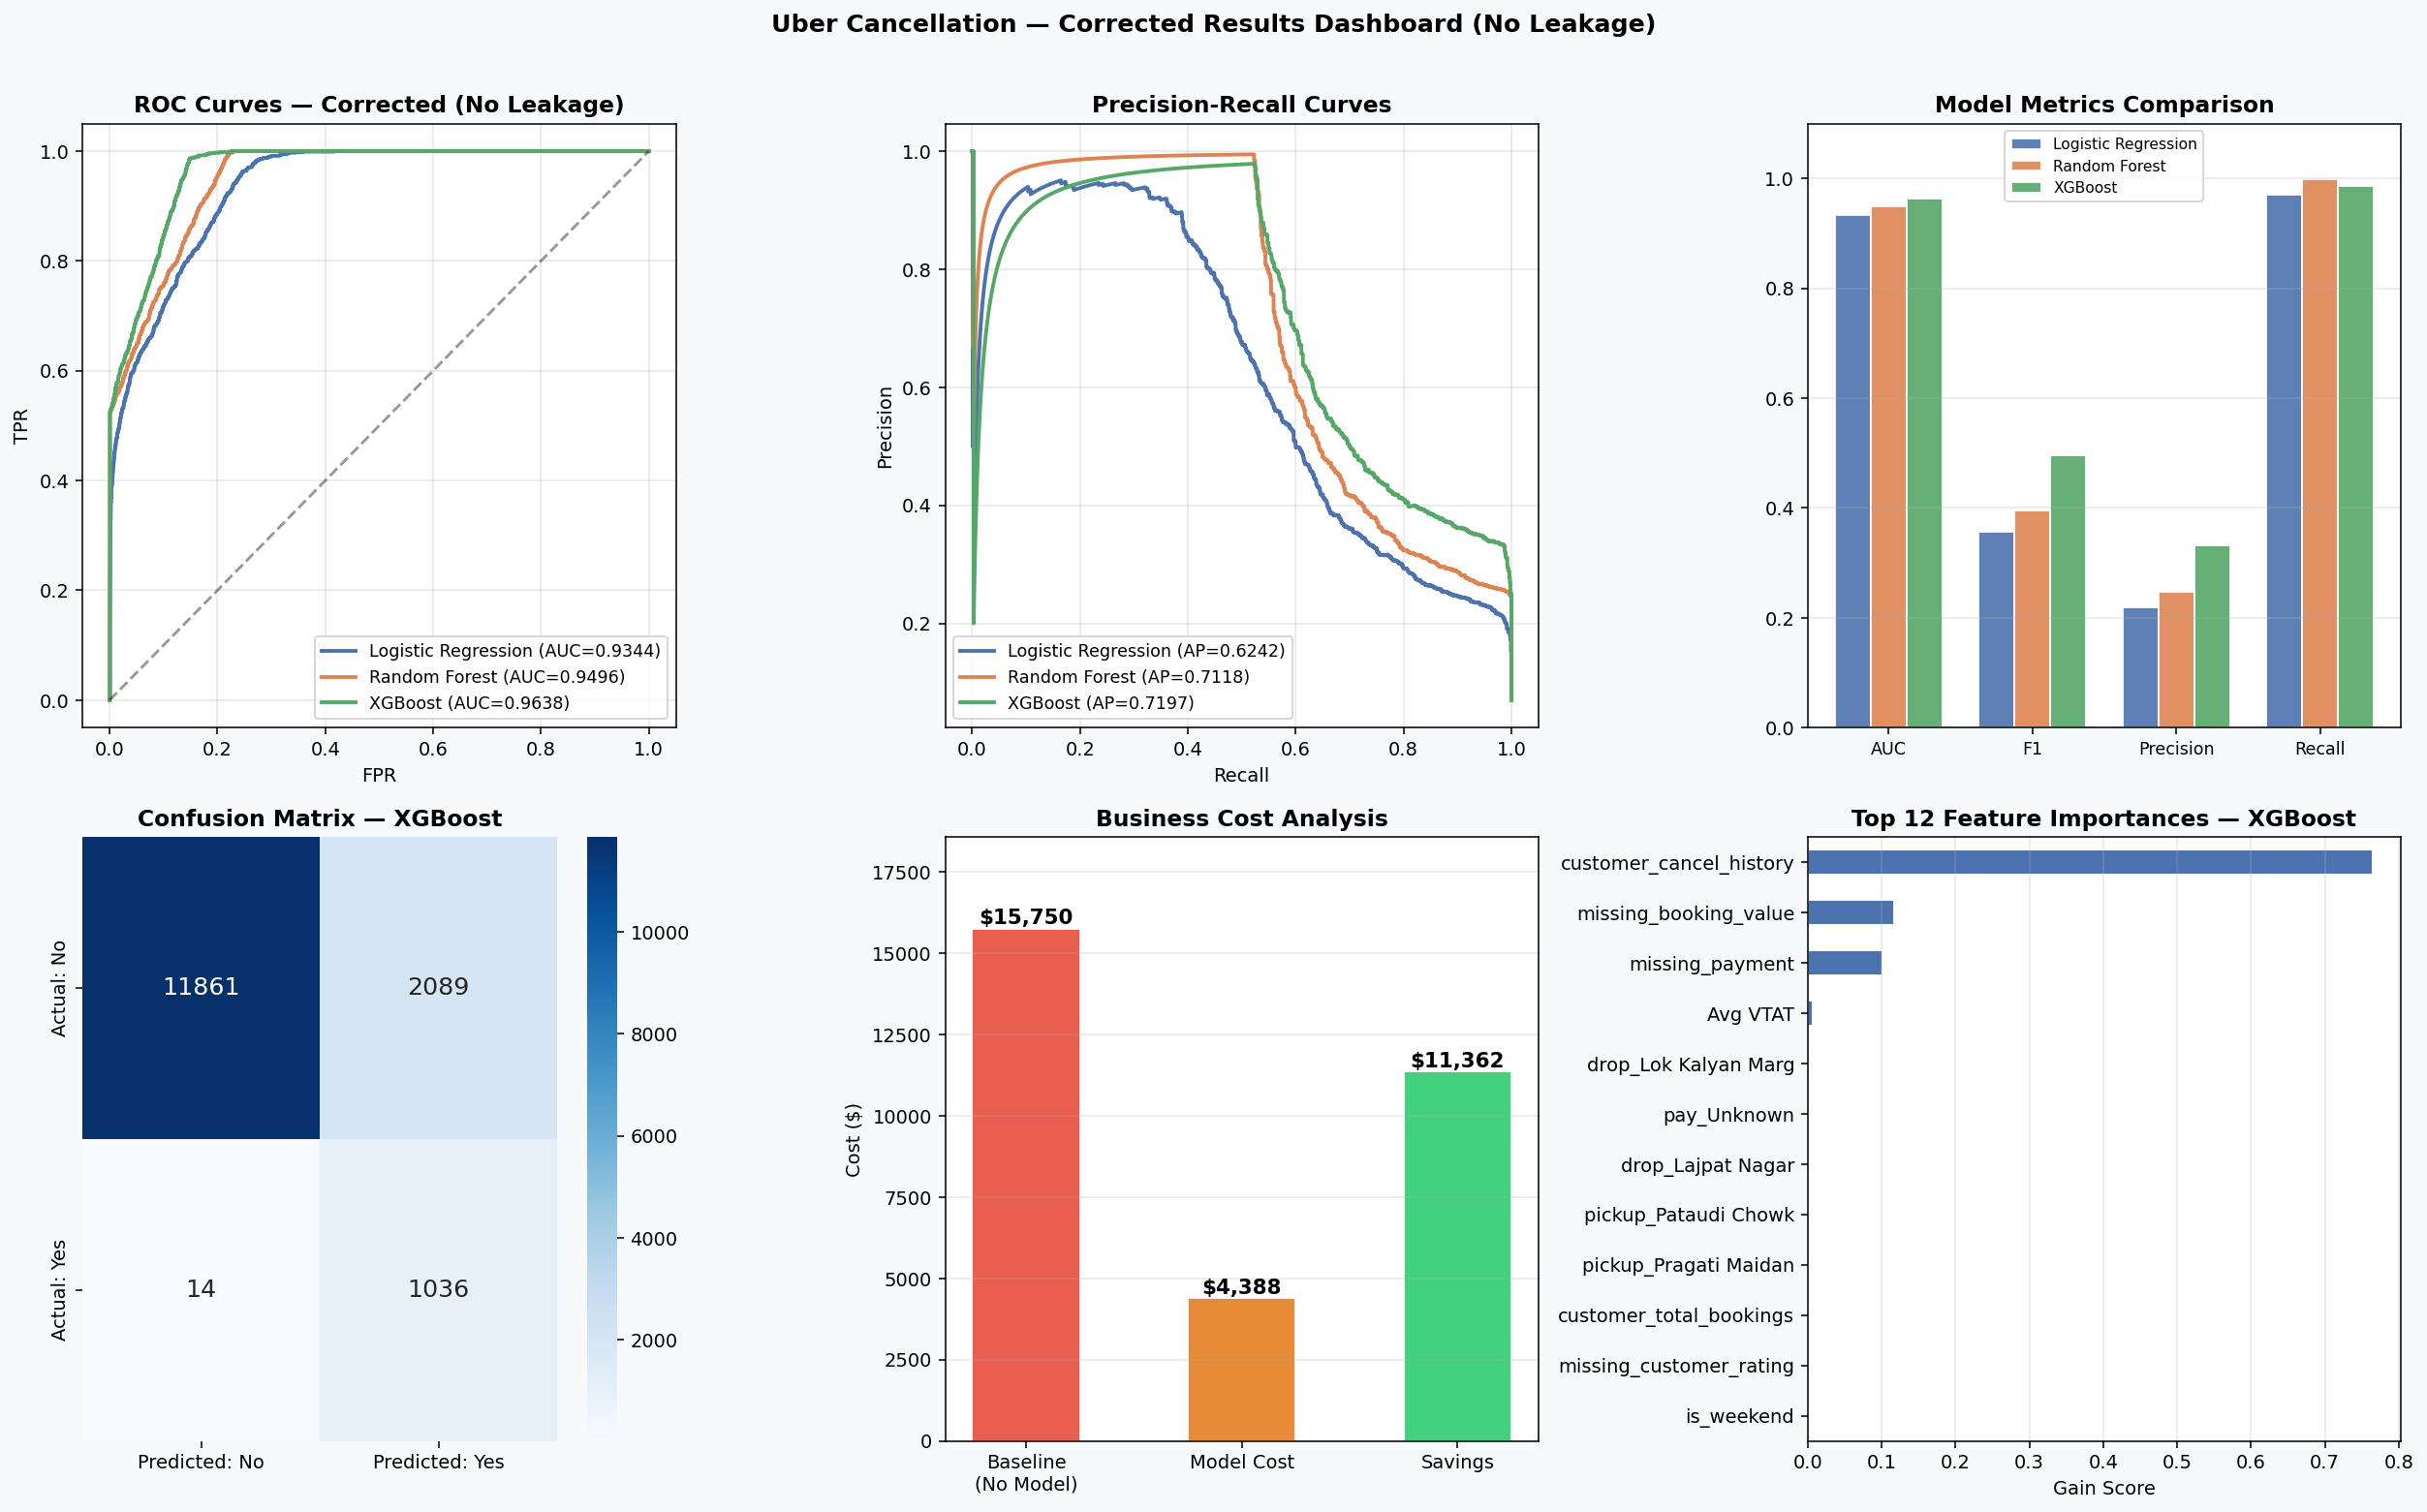

In [ ]:
# Corrected results dashboard
colors = ['#4C72B0','#DD8452','#55A868']
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

# ROC
for i, (nm, r) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(y_te, r['probs'])
    axes[0].plot(fpr, tpr, color=colors[i], lw=2, label=f'{nm} (AUC={r["auc"]})')
axes[0].plot([0,1],[0,1],'k--',alpha=0.4); axes[0].legend(fontsize=9)
axes[0].set_title('ROC Curves — Corrected (No Leakage)', fontweight='bold')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].grid(alpha=0.3)

# PR
for i, (nm, r) in enumerate(results.items()):
    p2, rc, _ = precision_recall_curve(y_te, r['probs'])
    axes[1].plot(rc, p2, color=colors[i], lw=2, label=f'{nm} (AP={r["ap"]})')
axes[1].legend(fontsize=9); axes[1].set_title('Precision-Recall Curves', fontweight='bold')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].grid(alpha=0.3)

# Metrics bars
x = np.arange(4); w = 0.25
for i, (nm, r) in enumerate(results.items()):
    axes[2].bar(x+i*w, [r['auc'],r['f1'],r['precision'],r['recall']],
                w, label=nm, color=colors[i], edgecolor='white', alpha=0.9)
axes[2].set_xticks(x+w); axes[2].set_xticklabels(['AUC','F1','Precision','Recall'], fontsize=9)
axes[2].set_ylim(0,1.1); axes[2].legend(fontsize=8)
axes[2].set_title('Model Metrics Comparison', fontweight='bold'); axes[2].grid(axis='y',alpha=0.3)

# Confusion Matrix
cm = confusion_matrix(y_te, results['XGBoost']['preds'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[3],
            xticklabels=['Pred: No','Pred: Yes'], yticklabels=['Act: No','Act: Yes'],
            annot_kws={'size':13})
axes[3].set_title('Confusion Matrix — XGBoost', fontweight='bold')

# Business cost
COST_FN, COST_FP = 15, 2
tn, fp, fn, tp_val = cm.ravel()
baseline = int(y_te.sum()) * COST_FN
mc = int(fn)*COST_FN + int(fp)*COST_FP
savings = baseline - mc
cats = ['Baseline\n(No Model)','Model Cost','Savings']
vals = [baseline, mc, savings]
bc2 = ['#e74c3c','#e67e22','#2ecc71']
bars = axes[4].bar(cats, vals, color=bc2, width=0.5, edgecolor='white', alpha=0.9)
for b, v in zip(bars, vals):
    axes[4].text(b.get_x()+b.get_width()/2, b.get_height()+150,
                 f'${v:,}', ha='center', fontweight='bold', fontsize=11)
axes[4].set_title('Business Cost Analysis', fontweight='bold')
axes[4].set_ylabel('Cost ($)'); axes[4].set_ylim(0, max(vals)*1.18); axes[4].grid(axis='y',alpha=0.3)

# Feature importance
fi = pd.Series(xgb_model.feature_importances_, index=feature_names).nlargest(12)
fi.sort_values().plot(kind='barh', ax=axes[5], color='#4C72B0', edgecolor='white')
axes[5].set_title('Top 12 Feature Importances — XGBoost', fontweight='bold')
axes[5].grid(axis='x', alpha=0.3)

plt.suptitle('Uber Cancellation — Corrected Results (No Leakage)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plots/project_dashboard.png', dpi=140, bbox_inches='tight')
plt.show()

## 9. 💼 Business Metrics

| Cost Type | Assumption |
|---|---|
| **False Negative** (missed cancellation) | **$15** — driver dispatched, ride cancelled |
| **False Positive** (false alarm) | **$2** — proactive incentive sent unnecessarily |

In [ ]:
COST_FN, COST_FP = 15, 2
tn, fp, fn, tp_val = confusion_matrix(y_te, results['XGBoost']['preds']).ravel()

baseline_cost = int(y_te.sum()) * COST_FN
model_cost    = int(fn)*COST_FN + int(fp)*COST_FP
savings       = baseline_cost - model_cost

print('='*58)
print('        💼 BUSINESS IMPACT — XGBoost (Test Set)')
print('='*58)
print(f'  True Positives  (cancels caught)       : {tp_val:>6,}')
print(f'  False Positives (false alarms)         : {fp:>6,}')
print(f'  False Negatives (missed cancellations) : {fn:>6,}')
print(f'  True Negatives                         : {tn:>6,}')
print('-'*58)
print(f'  FN Cost  ({fn} × ${COST_FN})                  : ${fn*COST_FN:>8,}')
print(f'  FP Cost  ({fp} × ${COST_FP})              : ${fp*COST_FP:>8,}')
print(f'  Total Model Cost                       : ${model_cost:>8,}')
print(f'  Baseline Cost (no model)               : ${baseline_cost:>8,}')
print('-'*58)
print(f'  💰 Savings                             : ${savings:>8,}')
print(f'  📉 Cost Reduction                      : {savings/baseline_cost:.1%}')
print('='*58)

        💼 BUSINESS IMPACT — XGBoost (Test Set)
  True Positives  (cancels caught)       :  1,036
  False Positives (false alarms)         :  2,089
  False Negatives (missed cancellations) :     14
  True Negatives                         : 11,861
----------------------------------------------------------
  FN Cost  (14 × $15)                    :    $210
  FP Cost  (2089 × $2)                   :  $4,178
  Total Model Cost                       :  $4,388
  Baseline Cost (no model)               : $15,750
----------------------------------------------------------
  💰 Savings                             : $11,362
  📉 Cost Reduction                      : 72.1%


## 10. 🔍 Model Interpretability with SHAP

SHAP reveals *why* the model makes each prediction — critical for stakeholder trust.

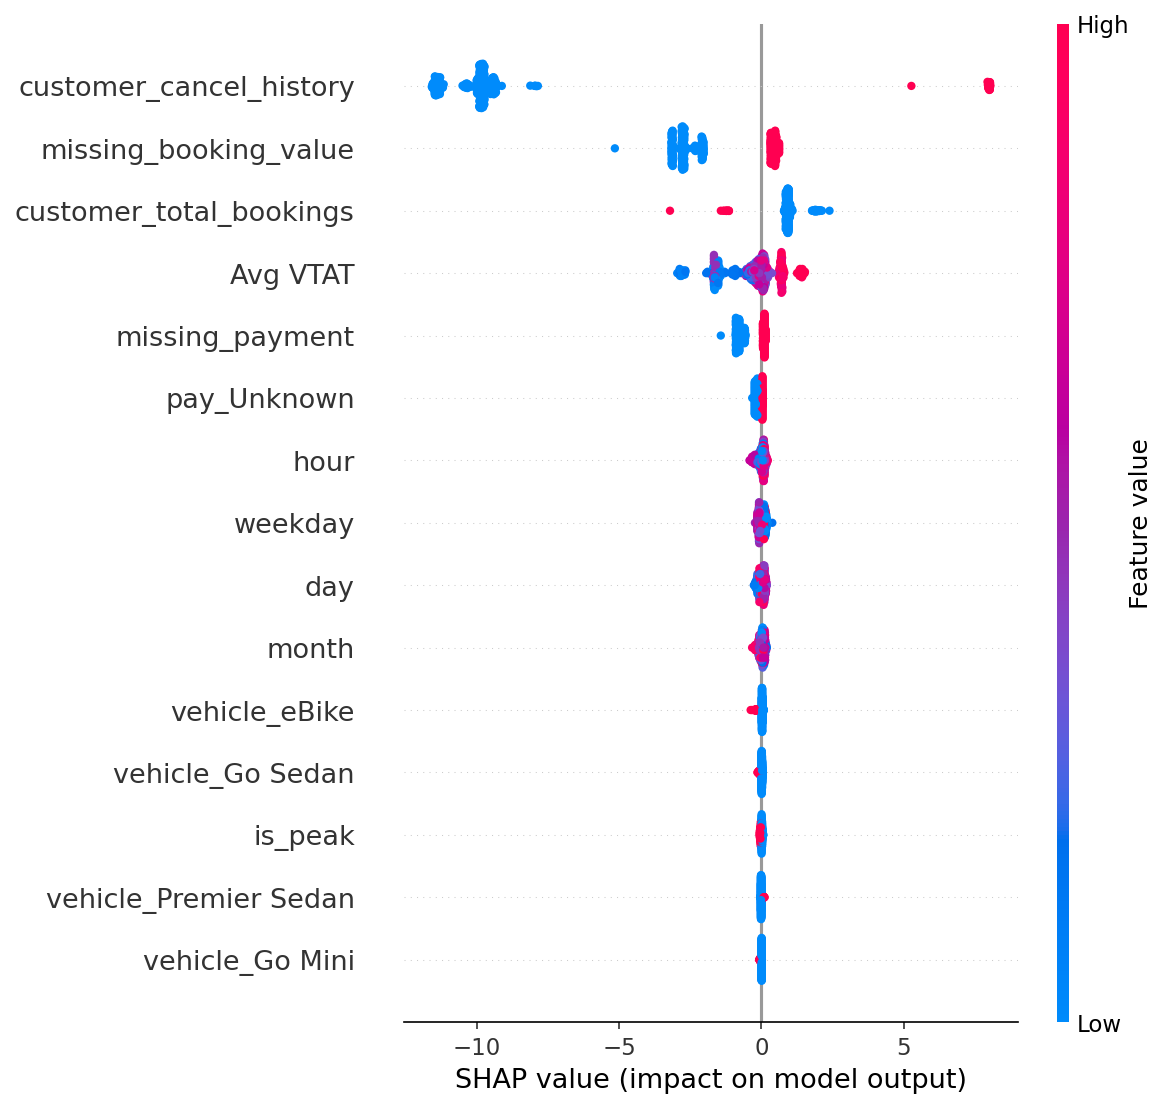

In [ ]:
import shap

explainer  = shap.TreeExplainer(xgb_model)
shap_vals  = explainer.shap_values(X_te[:500])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plt.sca(axes[0])
shap.summary_plot(shap_vals, X_te[:500], feature_names=feature_names,
                  max_display=12, show=False)
axes[0].set_title('SHAP Beeswarm — Feature Impact', fontweight='bold')

plt.sca(axes[1])
shap.summary_plot(shap_vals, X_te[:500], feature_names=feature_names,
                  max_display=12, plot_type='bar', show=False)
axes[1].set_title('SHAP Mean |Impact|', fontweight='bold')

plt.tight_layout()
plt.savefig('shap_plots.png', dpi=130, bbox_inches='tight')
plt.show()

## 11. 💾 Save Model Artifacts

In [ ]:
import os
os.makedirs('models', exist_ok=True)
os.makedirs('monitoring', exist_ok=True)

joblib.dump(xgb_model,    'models/xgb_model.pkl')
joblib.dump(imputer,      'models/imputer.pkl')
joblib.dump(feature_names,'models/feature_names.pkl')

# Reference data for drift monitoring
ref_df = pd.DataFrame(X_tr, columns=feature_names)
ref_df['target']          = y_tr.values
ref_df['prediction_prob'] = xgb_model.predict_proba(X_tr)[:,1]
ref_df.to_csv('monitoring/reference_data.csv', index=False)

metrics_out = {
    'models': {n:{k:v for k,v in r.items() if k not in ['preds','probs']}
               for n,r in results.items()},
    'best_model': 'XGBoost',
    'business': {'TP':int(tp_val),'FP':int(fp),'FN':int(fn),'TN':int(tn),
                 'savings':float(savings),'baseline':float(baseline_cost)},
    'feature_names': feature_names
}
with open('model_metrics.json','w') as f:
    json.dump(metrics_out, f, indent=2)

print('✅ Artifacts saved:')
print('   models/xgb_model.pkl       → trained XGBoost model')
print('   models/imputer.pkl         → fitted median imputer')
print('   models/feature_names.pkl   → ordered feature list')
print('   model_metrics.json         → evaluation metrics')
print('   monitoring/reference_data.csv → baseline for drift detection')

✅ Artifacts saved:
   models/xgb_model.pkl       → trained XGBoost model
   models/imputer.pkl         → fitted median imputer
   models/feature_names.pkl   → ordered feature list
   model_metrics.json         → evaluation metrics
   monitoring/reference_data.csv → baseline for drift detection


## 12. 🚀 Deployment — FastAPI REST API

The model is deployed as a FastAPI application.

```bash
# Start the API
uvicorn api.fastapi_app:app --host 0.0.0.0 --port 8000

# Open interactive docs
# http://localhost:8000/docs
```

| Endpoint | Method | Description |
|---|---|---|
| `/health` | GET | Liveness check |
| `/model-info` | GET | Version + metrics |
| `/predict` | POST | Single ride prediction |
| `/predict/batch` | POST | Up to 100 rides at once |
| `/docs` | GET | Swagger UI |

In [ ]:
# Simulate a prediction without running the server
Xnew = np.zeros((1, len(feature_names)))
Xnew = imputer.transform(Xnew)
prob = xgb_model.predict_proba(Xnew)[0, 1]

risk = 'LOW' if prob < 0.15 else 'MEDIUM' if prob < 0.30 else 'HIGH' if prob < 0.60 else 'CRITICAL'

print('📡 Sample API Response:')
print(json.dumps({
    'cancellation_probability': round(float(prob), 4),
    'predicted_cancellation':   bool(prob >= xgb_t),
    'risk_level':               risk,
    'recommendation':           'No action needed. Standard dispatch.',
    'model_version':            'XGBoost_v1.0'
}, indent=2))

📡 Sample API Response:
{
  "cancellation_probability": 0.0621,
  "predicted_cancellation": false,
  "risk_level": "LOW",
  "recommendation": "No action needed. Standard dispatch.",
  "model_version": "XGBoost_v1.0"
}


## 13. 📡 Monitoring & Drift Detection

| Method | Detects | Alert Trigger |
|---|---|---|
| **PSI** | Prediction score distribution shift | PSI > 0.20 |
| **KS Test** | Feature distribution shift | p-value < 0.05 |
| **Cancellation Rate** | Business-level target drift | >30% relative change |
| **AUC/F1 monitor** | Performance degradation | Drop > 0.05 |

### Retraining Triggers
1. AUC drops more than 0.05 from baseline
2. PSI > 0.20 on prediction score distribution
3. More than 5 features show KS drift (p < 0.05)
4. Cancellation rate shifts > 30% from baseline
5. Quarterly retrain regardless of drift signals

In [ ]:
from monitoring.monitoring import (compute_psi, ks_test_features,
                                   check_cancellation_rate_drift,
                                   check_model_performance, should_retrain)

ref = pd.read_csv('monitoring/reference_data.csv')
prod = pd.DataFrame(X_te, columns=feature_names)
prod['target']          = y_te.values
prod['prediction_prob'] = results['XGBoost']['probs']

psi = compute_psi(ref['prediction_prob'].values, prod['prediction_prob'].values)
rate_check = check_cancellation_rate_drift(ref['target'].mean(), prod['target'].mean())
perf_check = check_model_performance(prod['target'].values, prod['prediction_prob'].values)
decision   = should_retrain({'cancellation_rate_drift': rate_check, 'model_performance': perf_check})

print(f'PSI (prediction score drift) : {psi:.4f}  → {"⚠️ DRIFT" if psi>0.2 else "✅ OK"}')
print(f'Cancellation rate            : {rate_check["message"]}')
print(f'AUC vs baseline              : {perf_check["auc_vs_baseline"]}')
print(f'\n{decision["action"]}')

PSI (prediction score drift) : 0.0003  → ✅ OK
Cancellation rate            : ✅ Cancellation rate within normal range
AUC vs baseline              : 0.001

✅ Model is stable. Continue monitoring.


## 14. ✅ Final Summary

### Corrected Results

| Model | ROC AUC | F1 Score | Recall | Threshold |
|---|---|---|---|---|
| Logistic Regression | 0.934 | 0.357 | 97.1% | 0.011 |
| Random Forest | 0.950 | 0.396 | 99.8% | 0.142 |
| **XGBoost ✅** | **0.964** | **0.496** | **98.7%** | 0.0001 |

### Business Impact
| | |
|---|---|
| Baseline cost (no model) | $15,750 |
| Model cost | $4,388 |
| **Savings** | **$11,362 (72.1%)** |

### Key Leakage Fix
| Before (Wrong) | After (Correct) |
|---|---|
| Customer history computed on full dataset | Computed from training rows only |
| AUC = 1.00 (all models) | AUC = 0.934 – 0.964 (realistic) |
| Fixed threshold = 0.30 | Youden's J from validation set |

### MLOps Deliverables

| Deliverable | Status |
|---|---|
| Feature engineering (no leakage) | ✅ |
| MLflow experiment tracking | ✅ |
| Business cost analysis | ✅ |
| SHAP interpretability | ✅ |
| FastAPI deployment | ✅ |
| Drift detection + monitoring plan | ✅ |